# Comparative Analysis of Pad Geometry Sweeps

Starting analysis...
Successfully loaded and aggregated 60 data points from 10 files.
Calculated EJ/EC ratio and added it to the plots.

Generating Figure 1: Properties vs. pad_width


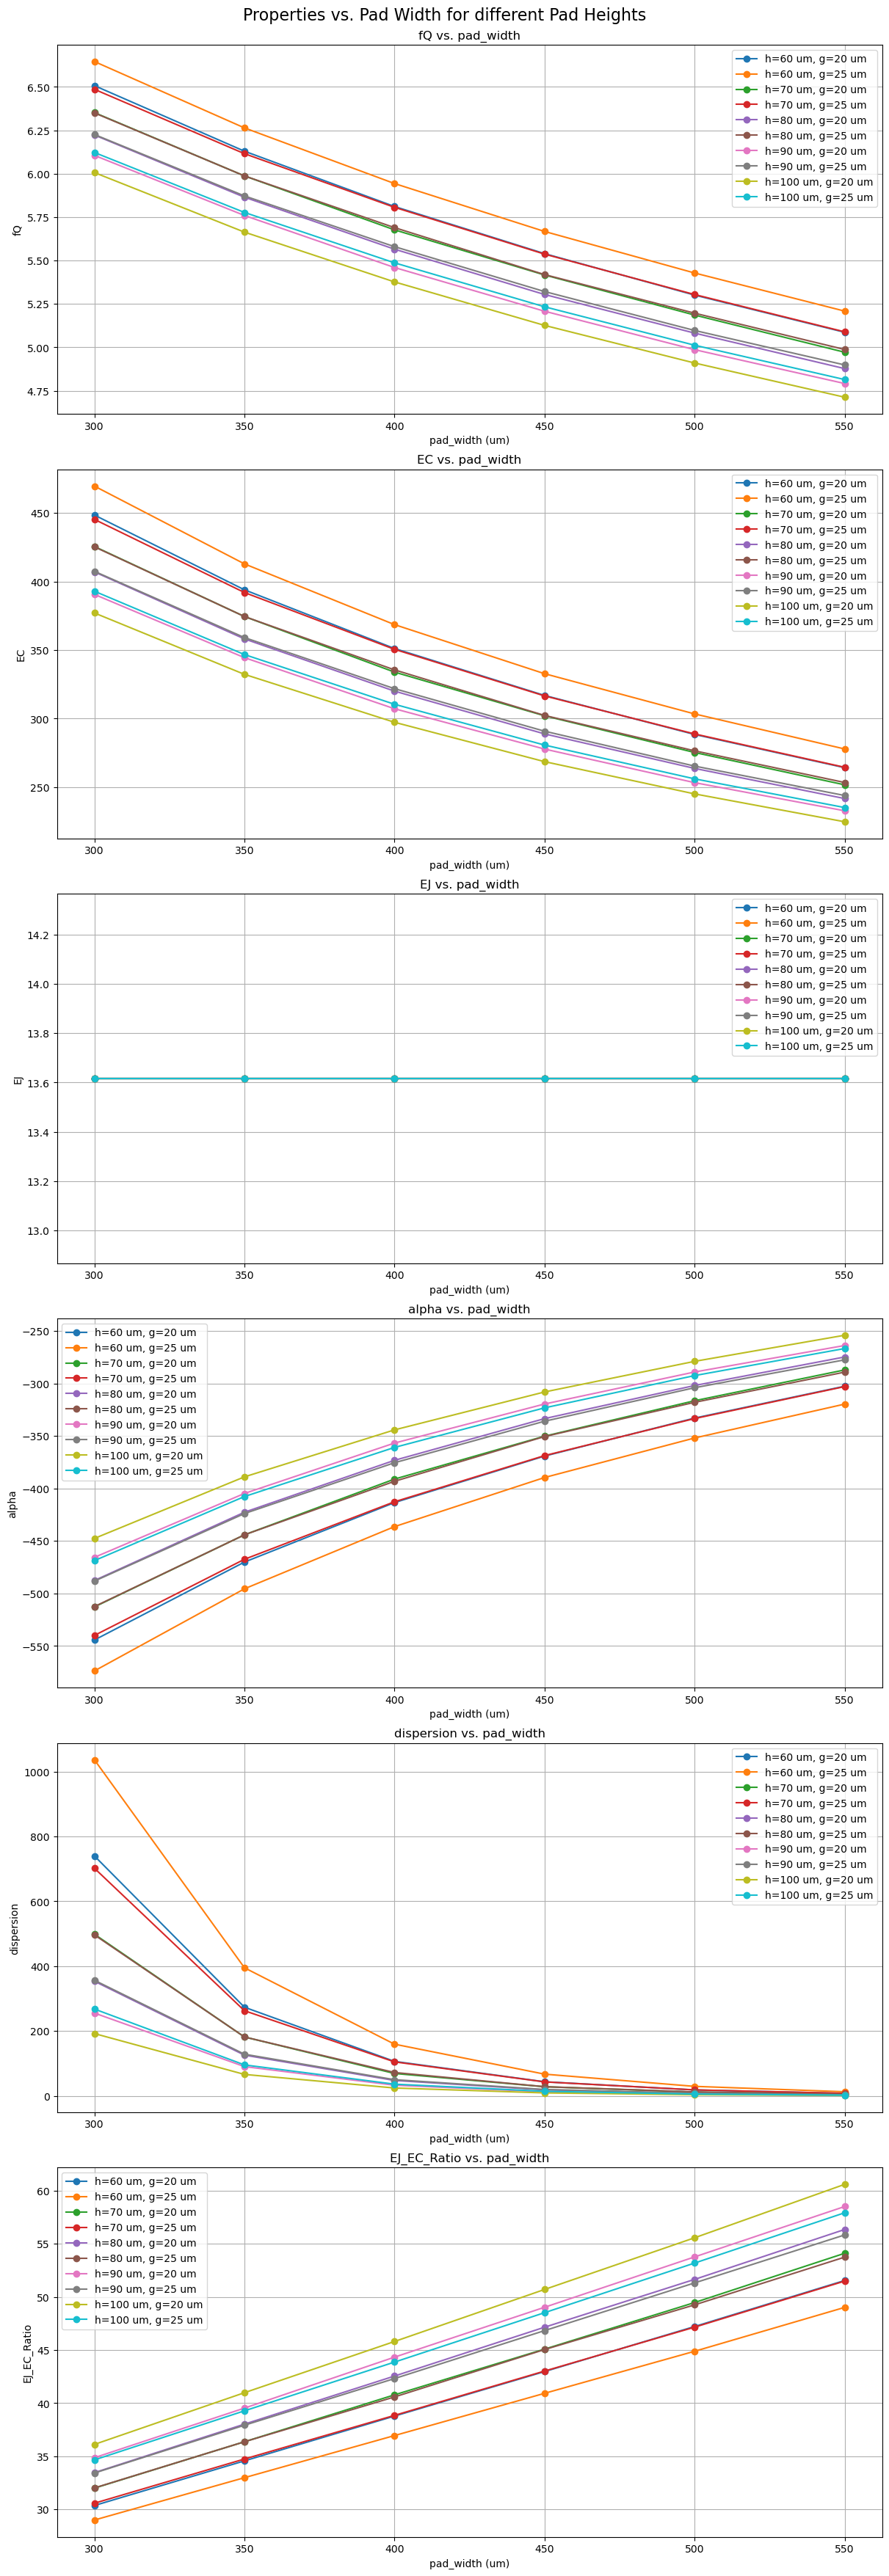


Generating Figure 2: Properties vs. pad_height


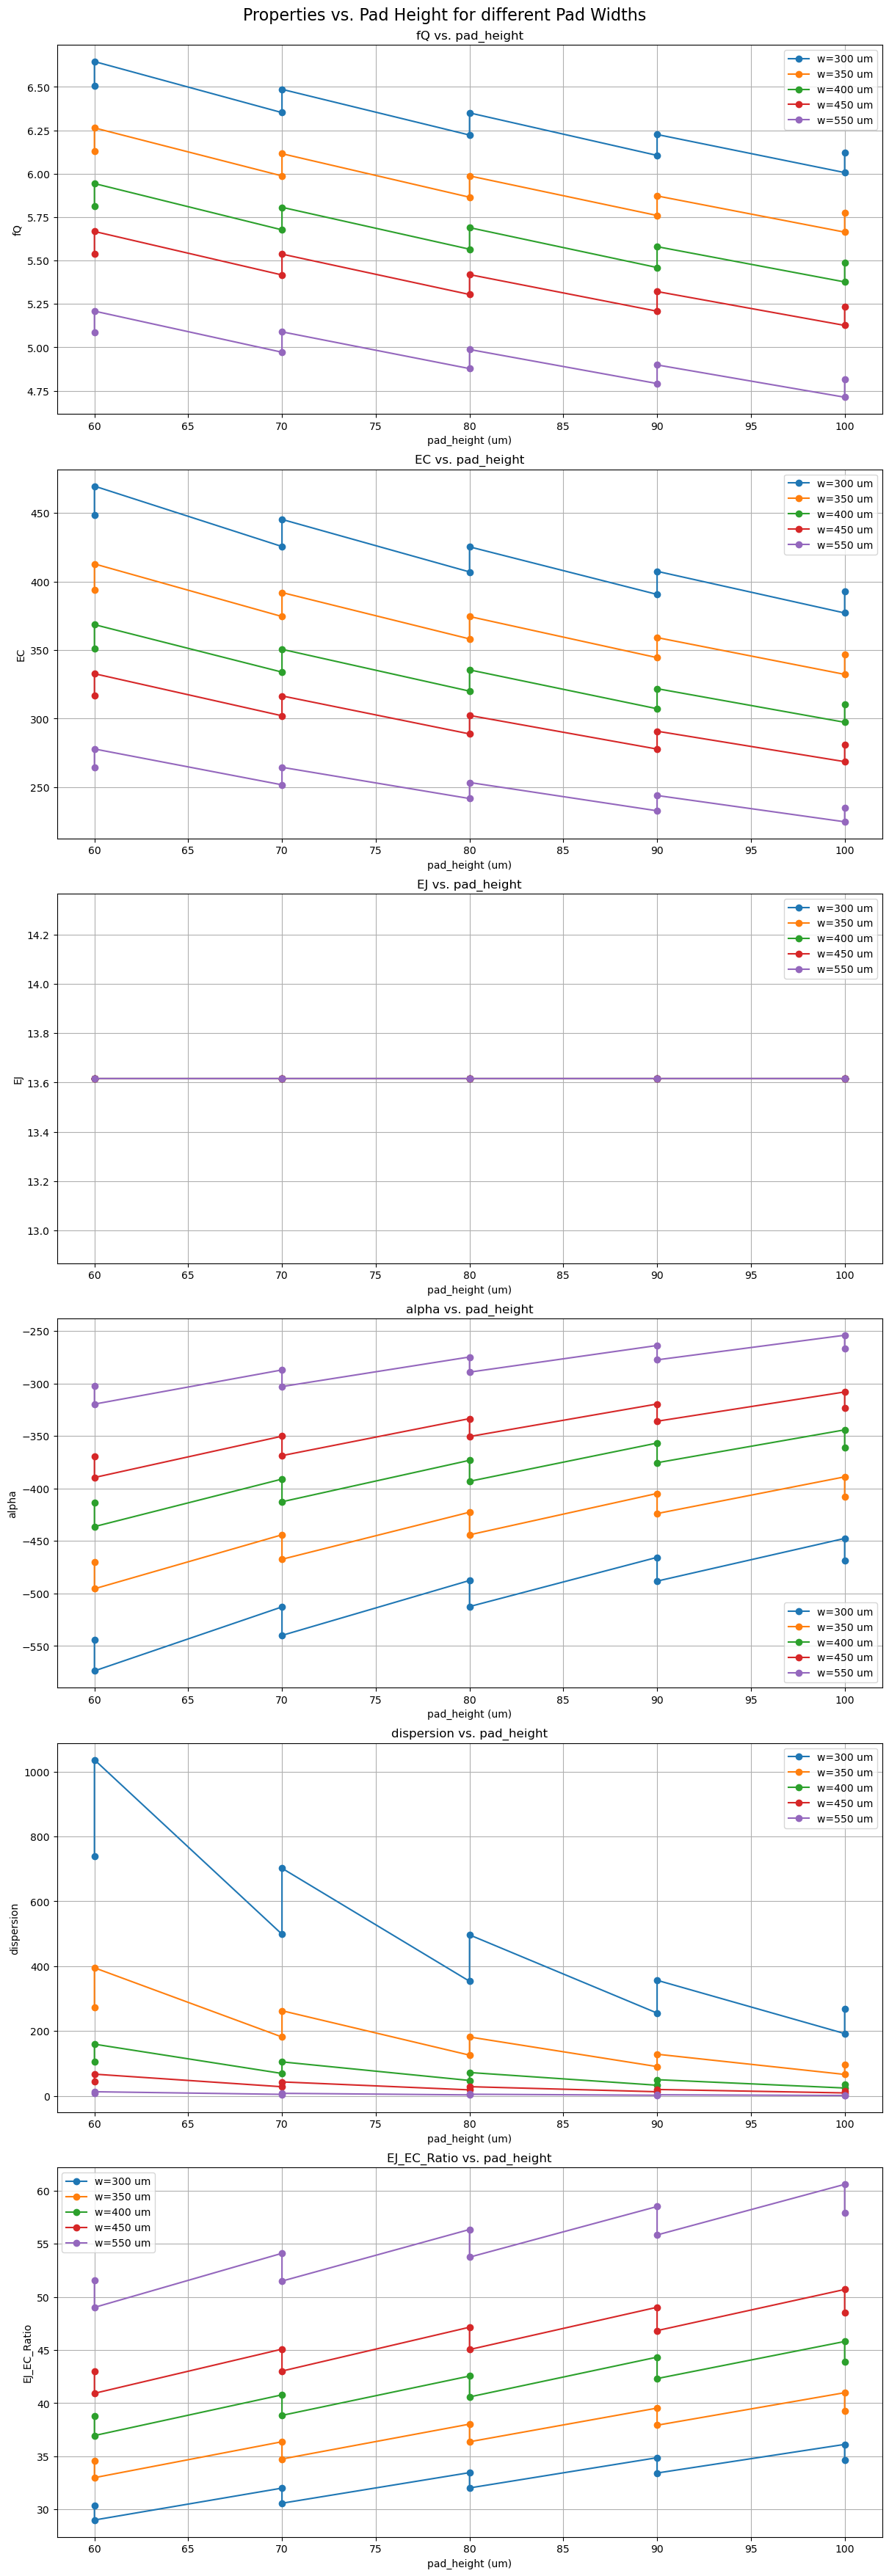

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import os
import glob
import numpy as np

print("Starting analysis...")

# Function to extract numeric values from string columns
def clean_col(series):
    return pd.to_numeric(series.astype(str).str.extract(r'(\d+\.?\d*)', expand=False))

# --- 1. Data Aggregation ---
all_data = []
path_to_search = './'
csv_files = glob.glob(os.path.join(path_to_search, '*_data.csv'))

param_re = re.compile(r'pad_width_\d+_\d+_pad_height_(\d+)_pad_gap_(\d+)_data\.csv')

for file_path in csv_files:
    file_name = os.path.basename(file_path)
    match = param_re.match(file_name)
    if match:
        pad_height_val = int(match.group(1))
        try:
            df = pd.read_csv(file_path)
            df['pad_height'] = pad_height_val
            all_data.append(df)
        except Exception as e:
            print(f"Could not process {file_name}: {e}")

if not all_data:
    print("No data was loaded. Please check filenames and paths.")
else:
    master_df = pd.concat(all_data, ignore_index=True)
    master_df['pad_width'] = clean_col(master_df['pad_width'])
    master_df['pad_height'] = clean_col(master_df['pad_height'])
    master_df['pad_gap'] = clean_col(master_df['pad_gap'])

    master_df.dropna(subset=['pad_width', 'pad_height', 'pad_gap'], inplace=True)
    print(f"Successfully loaded and aggregated {len(master_df)} data points from {len(csv_files)} files.")

    # --- 2. Calculate EJ/EC Ratio ---
    properties = ['fQ', 'EC', 'EJ', 'alpha', 'dispersion']
    if 'EJ' in master_df.columns and 'EC' in master_df.columns:
        # Handle potential division by zero or non-numeric values
        master_df['EJ_EC_Ratio'] = 1000 * master_df['EJ'] / master_df['EC'].replace(0, np.nan)
        properties.append('EJ_EC_Ratio')
        print("Calculated EJ/EC ratio and added it to the plots.")

    # --- 3. Figure 1: Plotting vs. pad_width ---
    print("\nGenerating Figure 1: Properties vs. pad_width")
    fig1, axes1 = plt.subplots(len(properties), 1, figsize=(12, 35), constrained_layout=True)
    fig1.suptitle('Properties vs. Pad Width for different Pad Heights', fontsize=16)
    
    unique_heights = sorted(master_df['pad_height'].unique())

    unique_gaps = sorted(master_df['pad_gap'].unique())

    for i, prop in enumerate(properties):
        ax = axes1[i]
        for height in unique_heights:
            for gap in unique_gaps:
                subset = master_df[(master_df['pad_height'] == height) & (master_df['pad_gap'] == gap)].sort_values('pad_width')
                ax.plot(subset['pad_width'], subset[prop], marker='o', linestyle='-', label=f'h={height} um, g={gap} um')
        ax.set_xlabel('pad_width (um)')
        ax.set_ylabel(prop)
        ax.set_title(f'{prop} vs. pad_width')
        ax.legend()
        ax.grid(True)
    plt.show()

    # --- 4. Figure 2: Plotting vs. pad_height ---
    print("\nGenerating Figure 2: Properties vs. pad_height")
    fig2, axes2 = plt.subplots(len(properties), 1, figsize=(12, 35), constrained_layout=True)
    fig2.suptitle('Properties vs. Pad Height for different Pad Widths', fontsize=16)

    unique_widths = sorted(master_df['pad_width'].unique())
    # Select a few widths for plot clarity
    width_indices = np.linspace(0, len(unique_widths) - 1, 5, dtype=int)
    selected_widths = [unique_widths[i] for i in width_indices]

    for i, prop in enumerate(properties):
        ax = axes2[i]
        for width in selected_widths:
            subset = master_df[master_df['pad_width'] == width].sort_values('pad_height')
            ax.plot(subset['pad_height'], subset[prop], marker='o', linestyle='-', label=f'w={width} um')
        ax.set_xlabel('pad_height (um)')
        ax.set_ylabel(prop)
        ax.set_title(f'{prop} vs. pad_height')
        ax.legend()
        ax.grid(True)
    plt.show()


In [ ]:
master_df['Aspect_Ratio'] = master_df['pad_width']/master_df['pad_height']


In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# 1. Find all unique pad heights and sort them
unique_heights = np.sort(master_df['pad_height'].unique())
n_colors = len(unique_heights)

# 2. Map each unique height to an integer index (0, 1, 2, ...)
category_map = {height: i for i, height in enumerate(unique_heights)}
color_indices = master_df['pad_height'].map(category_map)

# 3. Request a discrete version of a colormap by specifying the exact number of colors needed
cmap = plt.get_cmap('viridis', n_colors)

# 4. Create the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot using the discrete integer indices for the colors
scatter = ax.scatter(
    x=master_df['Aspect_Ratio'], 
    y=master_df['EJ_EC_Ratio'], 
    c=color_indices, 
    cmap=cmap, 
    edgecolor='k',    # Adding a subtle black border to the dots looks nice
    alpha=0.8         # Slight transparency in case points overlap
)

# 5. Build and format the discrete colorbar
cbar = plt.colorbar(scatter, ticks=np.arange(n_colors))
cbar.set_ticklabels(unique_heights)
cbar.set_label('Pad Height')

# Labels and title
ax.set_xlabel('Aspect Ratio')
ax.set_ylabel('EJ / EC Ratio')
ax.set_title('EJ/EC Ratio vs Aspect Ratio by Pad Height')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Clean data if necessary (Uncomment if your columns have string units like '10 um')
# master_df['pad_height'] = master_df['pad_height'].astype(str).str.replace(' um', '', regex=False).astype(float)
# master_df['pad_width'] = master_df['pad_width'].astype(str).str.replace(' um', '', regex=False).astype(float)

# --- SCATTER PLOT SETUP (Pad Height) ---
unique_heights = np.sort(master_df['pad_height'].unique())
n_colors = len(unique_heights)

category_map = {height: i for i, height in enumerate(unique_heights)}
color_indices = master_df['pad_height'].map(category_map)
cmap_scatter = plt.get_cmap('viridis', n_colors)

fig, ax = plt.subplots(figsize=(10, 6)) # Made slightly wider to accommodate the legend

# Draw the scatter points
scatter = ax.scatter(
    x=master_df['Aspect_Ratio'], 
    y=master_df['EJ_EC_Ratio'], 
    c=color_indices, 
    cmap=cmap_scatter, 
    edgecolor='k',
    alpha=1.0,
    zorder=3 # Ensures dots are drawn on top of the lines
)

# Build the discrete colorbar for pad_height
cbar = plt.colorbar(scatter, ticks=np.arange(n_colors), ax=ax, pad=0.02)
cbar.set_ticklabels(unique_heights)
cbar.set_label('Pad Height')


# --- LINE PLOT SETUP (Pad Width) ---
unique_widths = np.sort(master_df['pad_width'].unique())
n_line_colors = len(unique_widths)
# Use a different colormap for lines to distinguish them from the scatter dots
cmap_lines = plt.get_cmap('tab10', n_line_colors) 

for i, width in enumerate(unique_widths):
    # Filter the dataframe for this specific pad_width
    group_df = master_df[master_df['pad_width'] == width]
    
    # Sort by Aspect_Ratio so the line connects points smoothly from left to right
    group_df = group_df.sort_values(by='Aspect_Ratio')
    
    # Plot the connecting lines
    ax.plot(
        group_df['Aspect_Ratio'], 
        group_df['EJ_EC_Ratio'], 
        color=cmap_lines(i), 
        label=f'{width}', 
        linewidth=2,
        alpha=0.6,
        zorder=2 # Draws lines behind the scatter dots
    )

# Add a legend for the lines, placing it outside the plot so it doesn't overlap
ax.legend(title='Pad Width', bbox_to_anchor=(0.88, 1), loc='upper left')

# --- FORMATTING ---
ax.set_xlabel('Aspect Ratio')
ax.set_ylabel('EJ / EC Ratio')
ax.set_title('EJ/EC Ratio vs Aspect Ratio (Grouped by Pad Width & Height)')
plt.grid(True, linestyle='--', alpha=0.5, zorder=1)

# Adjust layout so the external legend isn't cut off
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# 1. Clean data if necessary (Uncomment if your columns have string units like '10 um')
# master_df['pad_height'] = master_df['pad_height'].astype(str).str.replace(' um', '', regex=False).astype(float)
# master_df['pad_width'] = master_df['pad_width'].astype(str).str.replace(' um', '', regex=False).astype(float)

# --- SCATTER PLOT SETUP (Pad Height) ---
unique_heights = np.sort(master_df['pad_height'].unique())
n_colors = len(unique_heights)

category_map = {height: i for i, height in enumerate(unique_heights)}
color_indices = master_df['pad_height'].map(category_map)
cmap_scatter = plt.get_cmap('viridis', n_colors)

fig, ax = plt.subplots(figsize=(10, 6))

# Draw the scatter points
scatter = ax.scatter(
    x=master_df['Aspect_Ratio'], 
    y=master_df['EJ_EC_Ratio'], 
    c=color_indices, 
    cmap=cmap_scatter, 
    edgecolor='k',
    alpha=1.0,
    zorder=3
)

# Build the discrete colorbar for pad_height
cbar = plt.colorbar(scatter, ticks=np.arange(n_colors), ax=ax, pad=0.02)
cbar.set_ticklabels(unique_heights)
cbar.set_label('Pad Height')


# --- SMOOTH CURVE PLOT SETUP (Pad Width) ---
unique_widths = np.sort(master_df['pad_width'].unique())
n_line_colors = len(unique_widths)
cmap_lines = plt.get_cmap('tab10', n_line_colors) 

for i, width in enumerate(unique_widths):
    # Filter and sort data by Aspect_Ratio so the X-axis is strictly increasing
    group_df = master_df[master_df['pad_width'] == width].sort_values(by='Aspect_Ratio')
    
    # Extract the raw X and Y coordinates
    x_data = group_df['Aspect_Ratio'].values
    y_data = group_df['EJ_EC_Ratio'].values
    
    # Splines require at least 2 points
    if len(x_data) > 1:
        # Determine spline degree (cubic 'k=3' by default, but drop to 1 or 2 if there are very few data points)
        k = min(3, len(x_data) - 1)
        
        # Generate 300 evenly spaced points between the minimum and maximum X values
        x_smooth = np.linspace(x_data.min(), x_data.max(), 300)
        
        # Fit the spline function and compute the smooth Y coordinates
        spline = make_interp_spline(x_data, y_data, k=k)
        y_smooth = spline(x_smooth)
        
        # Plot the smoothed curve
        ax.plot(
            x_smooth, 
            y_smooth, 
            color=cmap_lines(i), 
            label=f'{width}', 
            linewidth=2,
            alpha=0.6,
            zorder=2
        )

# Add an external legend for the pad_width lines
ax.legend(title='Pad Width', bbox_to_anchor=(0.88, 1), loc='upper left')

# --- FORMATTING ---
ax.set_xlabel('Aspect Ratio')
ax.set_ylabel('EJ / EC Ratio')
ax.set_title('EJ/EC Ratio vs Aspect Ratio (Smoothed by Pad Width)')
plt.grid(True, linestyle='--', alpha=0.5, zorder=1)

plt.tight_layout()
plt.show()


In [ ]:
master_df = master_df[master_df['pad_height'] >= 60 ]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- SCATTER PLOT SETUP (Pad Width) ---
# 1. Find all unique pad widths and sort them
unique_widths = np.sort(master_df['pad_width'].unique())
n_colors = len(unique_widths)

# 2. Map each unique width to an integer index
category_map_width = {width: i for i, width in enumerate(unique_widths)}
color_indices_width = master_df['pad_width'].map(category_map_width)

# 3. Create a discrete colormap for the scatter dots
cmap_scatter = plt.get_cmap('viridis', n_colors)

fig, ax = plt.subplots(figsize=(11, 6)) # Made a bit wider for potentially large legend

# 4. Draw the scatter points colored by pad_width
scatter = ax.scatter(
    x=master_df['Aspect_Ratio'], 
    y=master_df['EJ_EC_Ratio'], 
    c=color_indices_width, 
    cmap=cmap_scatter, 
    edgecolor='k',
    alpha=1.0,
    zorder=3
)

# 5. Build the discrete colorbar for pad_width
cbar = plt.colorbar(scatter, ticks=np.arange(n_colors), ax=ax, pad=0.02)
cbar.set_ticklabels(unique_widths)
cbar.set_label('Pad Width')


# --- STRAIGHT LINE PLOT SETUP (Pad Height) ---
unique_heights = np.sort(master_df['pad_height'].unique())
n_line_colors = len(unique_heights)

# Using 'tab20' in case there are up to 20 unique pad heights to maintain distinct colors
cmap_lines = plt.get_cmap('Reds', n_line_colors) 

for i, height in enumerate(unique_heights):
    # Filter and sort data by Aspect_Ratio for strict left-to-right line drawing
    group_df = master_df[master_df['pad_height'] == height].sort_values(by='Aspect_Ratio')
    
    # Plot standard straight lines between the points
    ax.plot(
        group_df['Aspect_Ratio'], 
        group_df['EJ_EC_Ratio'], 
        color=cmap_lines(i), 
        label=f'{height}', 
        linewidth=2,
        alpha=0.6,
        zorder=2
    )

# Add an external legend for the pad_height lines
# Use 2 columns (ncol=2) if there are a lot of heights so it fits nicely on the screen
num_columns = 2 if n_line_colors > 10 else 1
ax.legend(title='Pad Height', bbox_to_anchor=(0.88, 1), loc='upper left', ncol=num_columns)

# --- FORMATTING ---
ax.set_xlabel('Aspect Ratio')
ax.set_ylabel('EJ / EC Ratio')
# ax.set_xticks(range(2.5, 10, 1))
ax.set_yticks(range(15, 60, 5))
ax.set_title('EJ/EC Ratio vs Aspect Ratio (Lines by Pad Height, Dots by Pad Width)')
plt.grid(True, linestyle='--', alpha=0.5, zorder=1)

plt.tight_layout()
plt.show()


In [16]:
master_df[(master_df['pad_gap'] == '20 um') & (master_df['pad_height'] == 100)] 

,Iteration,pad_gap,pad_width,pad_height,cap_matrix,fQ,EC,EJ,alpha,dispersion,gbus,chi_in_MHz,cap_matrix_all_passes,lom_all_passes,is_converged,passes,EJ_EC_Ratio
0,0,20 um,300,100,coupler_lo...,6.006431,377.054039,13.6163,-447.561827,192.315265,[-55.31762849 58.61509266 -48.99848249],[ -1.92974195 1084.00430344 -17.33172844],"{1: array([[ 3.8625170e-14, -1.3063000e-16, -2...",fQ EC EJ ... ...,True,12,36.112330
1,1,20 um,350,100,coupler_lo...,5.663408,332.271553,13.6163,-388.946523,66.391971,[-50.57224976 54.49913809 -44.7775026 ],[-0.87542257 -9.47853585 -3.15197594],"{1: array([[ 3.8599350e-14, -9.5670000e-17, -2...",fQ EC EJ ... ...,True,11,40.979433
2,2,20 um,400,100,coupler_lo...,5.376621,297.320833,13.6163,-344.225051,24.535427,[-46.29311261 50.83389045 -40.97442741],[-0.47180698 -2.96354689 -1.21116197],"{1: array([[ 3.8563870e-14, -6.8350000e-17, -2...",fQ EC EJ ... ...,True,11,45.796656
3,3,20 um,450,100,coupler_lo...,5.126197,268.605640,13.6163,-308.135523,9.375370,[-42.20430678 47.46616027 -37.31729528],[-0.27614407 -1.35594555 -0.58521124],"{1: array([[ 3.8523130e-14, -4.8250000e-17, -2...",fQ EC EJ ... ...,True,11,50.692532
4,4,20 um,500,100,coupler_lo...,4.909479,245.082239,13.6163,-279.003259,3.761977,[-38.12645378 44.45755525 -33.73548484],[-0.16960417 -0.74796939 -0.31880876],"{1: array([[ 3.8480170e-14, -3.5330000e-17, -2...",fQ EC EJ ... ...,True,11,55.558085
5,5,20 um,550,100,coupler_lo...,4.712511,224.749855,13.6163,-254.134099,1.523449,[-33.94248587 41.61476119 -30.00697836],[-0.10508193 -0.45132848 -0.1805913 ],"{1: array([[ 3.8437000e-14, -2.9990000e-17, -2...",fQ EC EJ ... ...,True,11,60.584244
